In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy

In [2]:
# # Grid Search
# GrdSrchSamples_sca = 27
# GrdSrch_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-A1_PGCI-GrdSrch-[27]-P3O1/raw-data_2023-03-10_PtA1-PGCI-GrdSrch-[27]-P3O1_Stykke-4.csv")
# GrdSrch_df.rename(columns={"x1": "s1", "x2": "s2", "x3": "b1", "delta_polymer_mass_pct": "DeltaPolymerMass_pct", "polymer_start_mass_g": "StartPolymerMass_g", "polymer_end_mass_pct": "EndPolymerMass_pct"},inplace=True)
# GrdSrchMax_sca = -1 * np.min(np.array(GrdSrch_df["DeltaPolymerMass_pct"]))
# GrdSrchAvg_sca = -1 * np.average(np.array(GrdSrch_df["DeltaPolymerMass_pct"]))
# GrdSrchStd_sca = np.std(np.array(GrdSrch_df["DeltaPolymerMass_pct"]))

# print(GrdSrchSamples_sca)
# print(GrdSrchMax_sca)
# print(GrdSrchAvg_sca)
# print(GrdSrchStd_sca)

In [3]:
# Random Search
RndSrchSamples_sca = 27
RndSrch_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-A2_PGCI-RndSrch-[27]-P3O1/raw-data_2023-03-10_PtA2-PGCI-RndSrch-[27]-P3O1_Stykke-4.csv")
RndSrchMax_sca = -1 * np.min(np.array(RndSrch_df["delta_polymer_mass_pct"]))
RndSrchAvg_sca = -1 * np.average(np.array(RndSrch_df["delta_polymer_mass_pct"]))
RndSrchStd_sca = np.std(np.array(RndSrch_df["delta_polymer_mass_pct"]))

print(RndSrchSamples_sca)
print(RndSrchMax_sca)
print(RndSrchAvg_sca)
print(RndSrchStd_sca)

27
14.007758321412112
12.544760582315112
0.8776451378191571


In [4]:
# Probability Of Improvement
BOpt_8SP_3It_df = pd.read_csv("/Users/thomasdodd/Library/CloudStorage/OneDrive-MillfieldEnterprisesLimited/Cambridge/PhD/Project-1_BO4BT/ExperimentalSeries-1_PGXOpt/Part-C_HypOptComp_PGCI/Part-B5_PGCI-BOpt-[8,3,3,3,3,3,3,1]-P3O1/raw-data_2023-03-20_PtB5-PGCI-BOpt-[8,3,3,3,3,3,3,1]-P3O1-Stykke-4.csv")
BOpt_8SP_3It_df["s1"] = BOpt_8SP_3It_df["x1"]
BOpt_8SP_3It_df["s2"] = BOpt_8SP_3It_df["x2"]
BOpt_8SP_3It_df["b1"] = BOpt_8SP_3It_df["x3"]
BOpt_8SP_3It_df["DeltaPolymerMassPositive_pct"] = BOpt_8SP_3It_df["delta_polymer_mass_pct"]*-1
BOpt_8SP_3It_df

,mould_position,G_stoichiometry,CA_stoichiometry,IA_stoichiometry,x1,x2,x3,polymer_start_mass_g,polymer_end_mass_pct,delta_polymer_mass_pct,s1,s2,b1,DeltaPolymerMassPositive_pct
0,A1,1.0,0.989354,0.502368,0.574273,0.838241,0.726713,2.92,86.558126,-13.441874,0.574273,0.838241,0.726713,13.441874
1,A2,1.0,0.138614,1.034845,0.074273,0.338241,0.226713,3.38,85.987091,-14.012909,0.074273,0.338241,0.226713,14.012909
2,A3,1.0,0.470234,0.569463,0.324273,0.088241,0.476713,3.40,86.857362,-13.142638,0.324273,0.088241,0.476713,13.142638
3,A4,1.0,1.695973,0.036986,0.824273,0.588241,0.976713,2.86,88.632357,-11.367643,0.824273,0.588241,0.976713,11.367643
4,A5,1.0,0.676664,0.786529,0.949273,0.213241,0.351713,3.39,87.159687,-12.840313,0.949273,0.213241,0.351713,12.840313
5,A6,1.0,0.999834,0.254052,0.449273,0.713241,0.851713,3.19,86.923355,-13.076645,0.449273,0.713241,0.851713,13.076645
6,B1,1.0,0.081259,1.763554,0.199273,0.963241,0.101713,3.19,89.091765,-10.908235,0.199273,0.963241,0.101713,10.908235
7,B2,1.0,0.931999,0.582790,0.699273,0.463241,0.601713,3.10,86.234312,-13.765688,0.699273,0.463241,0.601713,13.765688
8,B3,1.0,0.091500,1.218500,0.080100,0.429500,0.147600,3.53,89.278178,-10.721822,0.080100,0.429500,0.147600,10.721822
9,B4,1.0,1.345100,0.012800,0.569800,0.799700,0.992900,3.03,91.622741,-8.377259,0.569800,0.799700,0.992900,8.377259


In [5]:
PI_8SP_3It_Progression = []
PI_8SP_3It_Progression.append(np.max(np.array(BOpt_8SP_3It_df["DeltaPolymerMassPositive_pct"].tolist()[0:8])))
for i in BOpt_8SP_3It_df["DeltaPolymerMassPositive_pct"].tolist()[8::]:
    ToBeat = np.max(np.array(PI_8SP_3It_Progression))
    if i > ToBeat:
        PI_8SP_3It_Progression.append(i)
    else:
        PI_8SP_3It_Progression.append(ToBeat)
PI_8SP_3It_ProgressionIndex = BOpt_8SP_3It_df.index.tolist()[7::]
PI_8SP_3It_ProgressionIndexPlusOne = [x+1 for x in PI_8SP_3It_ProgressionIndex]

In [6]:
PI_8SP_3It_ProgressionIndexPlusOneByThree = []
PI_8SP_3It_ProgressionByThree = []
for counter,(i,j) in enumerate(zip(PI_8SP_3It_ProgressionIndexPlusOne,PI_8SP_3It_Progression)):
    if float(counter+3)%3 == 0.0:
        PI_8SP_3It_ProgressionIndexPlusOneByThree.append(i)
        PI_8SP_3It_ProgressionByThree.append(j)

In [7]:
progression = [14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.012908907024908,14.639206860407173,14.639206860407173,14.639206860407173,14.639206860407173,14.639206860407173,14.639206860407173,14.639206860407173,16.66683313150004,16.66683313150004,17.279821796929994,17.279821796929994,20.775696958804065]
indexpositions = [8,9,10,11,12,13,14,15,16,17,18,19,20,21,21,22,23,24,25,26,27,27,28,28,29,29]

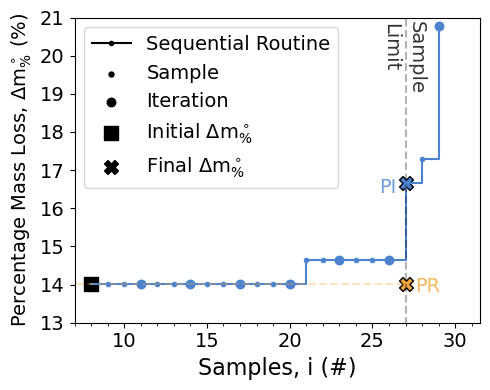

In [28]:
plt.scatter(PI_8SP_3It_ProgressionIndexPlusOne,PI_8SP_3It_Progression,c="#4c83d0",marker=".")
plt.plot(indexpositions,progression,c="#4c83d0")

plt.scatter(PI_8SP_3It_ProgressionIndexPlusOneByThree,PI_8SP_3It_ProgressionByThree,c="#4c83d0",marker=".",s=150)

plt.scatter(PI_8SP_3It_ProgressionIndexPlusOne[19],PI_8SP_3It_Progression[19],c="#4c83d0",marker="X",s=100,edgecolors="black")
# plt.scatter(27,GrdSrchMax_sca,color="#FF0000",marker="X",s=100,edgecolors="black")
plt.scatter(27,RndSrchMax_sca,color="#F0A638",marker="X",s=100,edgecolors="black")

# plt.hlines(GrdSrchMax_sca,0,27,linestyle="dashed",alpha=0.3,color="#FF0000")
# plt.hlines(SobSrchMax_sca,0,27,linestyle="dashed",alpha=0.3,color="#F8531C")
plt.hlines(RndSrchMax_sca,0,27,linestyle="dashed",alpha=0.3,color="#F0A638")
plt.vlines(27,0,22,color="black",linestyle="dashed",alpha=0.3)

plt.text(x=25.4,y=16.4,s="PI",color="#4c83d0",alpha=0.8,fontsize="14")
# plt.text(x=27.25,y=18.15,s="EI",color="#5ea402",alpha=0.8,fontsize="14")
# plt.text(x=27.25,y=14.7,s="Grid",color="#FF0000",alpha=0.8,fontsize="14")
# plt.text(x=27.25,y=14.45,s="Quasirandom",color="#F8531C",alpha=0.8,fontsize="14")
plt.text(x=27.6,y=13.8,s="PR",color="#F0A638",alpha=0.8,fontsize="14")
plt.text(x=27.05,y=19.1,s="Sample",color="black",rotation=-90,alpha=0.8,fontsize="14")
plt.text(x=25.5,y=19.7,s="Limit",color="black",rotation=-90,alpha=0.8,fontsize="14")

x = []
y = []
# plt.hlines(GrdSrchMax_sca,0,0.0000000001,linestyle="dashed",alpha=0.3,color="#000000",label="One-Shot Benchmark")
plt.plot(x,y,c="#000000",label="Sequential Routine",marker=".")
plt.scatter(x,y,marker=".",s=50,c="#000000",label="Sample")
plt.scatter(x,y,marker=".",s=150,c="#000000",label="Iteration")
plt.scatter(PI_8SP_3It_ProgressionIndexPlusOne[0],PI_8SP_3It_Progression[0],c="#000000",marker="s",s=100,label="Initial "+r"$\Delta$m$^\circ_\%$")
plt.scatter(x,y,marker="X",s=100,c="#000000",label="Final "+r"$\Delta$m$^\circ_\%$",edgecolors="black")

plt.gcf().set_size_inches(5, 4)
plt.xticks(np.arange(0, 31+1, 5),minor=False,fontsize="14")
plt.xticks(np.arange(0, 31+1, 1.0),minor=True)
plt.yticks(np.arange(13, 21+1, 1.0),minor=False,fontsize="14")
plt.xlim(left=7,right=31.5)
plt.ylim(bottom=13,top=21)
plt.xlabel("Samples, i (#)",fontsize="16")
plt.ylabel(r'Percentage Mass Loss, $\Delta$m$^\circ_\%$ (%)',fontsize="14")
plt.legend(loc='upper left',ncols=1,fontsize="14")
plt.tight_layout()
plt.savefig(fname='PracticalResultOverview.png',dpi=1000,format='png')